# 05 - Experiments: baseline augmentation and higher resolution

Same training setup as `04_train.ipynb` (now in `src/train.py`), three runs:

| run | augmentation | input | question it answers |
|---|---|---|---|
| `scenario_v1` | scenario | 256 px | first model (trained in notebook 04) |
| `light_v1` | light (flips, rotation, small jitter) | 256 px | baseline: what does the scenario augmentation add? |
| `scenario_320` | scenario | 320 px | do small lesions (cercospora, leaf miner) need more pixels? |

Validation images are clean BRACOL photos, so this notebook compares accuracy on *clean* images only. Whether scenario augmentation helps on home-style photos is measured later by the stress test.

Runs whose checkpoint already exists are skipped; set `RETRAIN = True` to train them again.

In [1]:
import sys
from pathlib import Path

ML = Path.cwd()
while not (ML / "src").exists():
    ML = ML.parent
sys.path.insert(0, str(ML))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from torch.utils.data import DataLoader

from src.config import CLASSES, SPLITS
from src.dataset import LeafDataset
from src.model import load_checkpoint
from src.train import CHECKPOINTS, RUNS, get_device, predict, train

device = get_device()
RETRAIN = False

EXPERIMENTS = [
    {"run": "light_v1", "aug": "light", "size": 256},
    {"run": "scenario_320", "aug": "scenario", "size": 320},
]
ALL_RUNS = ["scenario_v1"] + [e["run"] for e in EXPERIMENTS]

## Train

In [2]:
for exp in EXPERIMENTS:
    if not RETRAIN and (CHECKPOINTS / f"{exp['run']}_best.pt").exists():
        print(f"[{exp['run']}] checkpoint exists, skipping")
        continue
    train(exp)

[light_v1] epoch  1  train loss 3.140  val loss 1.712  val acc 0.552  val macro-F1 0.474  (15s)  <- best, saved


[light_v1] epoch  2  train loss 1.088  val loss 1.486  val acc 0.582  val macro-F1 0.560  (8s)  <- best, saved


[light_v1] epoch  3  train loss 0.884  val loss 0.591  val acc 0.776  val macro-F1 0.766  (8s)  <- best, saved


[light_v1] epoch  4  train loss 0.641  val loss 0.563  val acc 0.856  val macro-F1 0.817  (8s)  <- best, saved


[light_v1] epoch  5  train loss 0.528  val loss 0.548  val acc 0.841  val macro-F1 0.817  (8s)


...

[scenario_320] epoch 16  train loss 0.422  val loss 0.369  val acc 0.876  val macro-F1 0.859  (14s)


[scenario_320] epoch 17  train loss 0.412  val loss 0.346  val acc 0.881  val macro-F1 0.864  (15s)


[scenario_320] epoch 18  train loss 0.399  val loss 0.344  val acc 0.881  val macro-F1 0.866  (13s)


[scenario_320] epoch 19  train loss 0.388  val loss 0.360  val acc 0.876  val macro-F1 0.859  (14s)


[scenario_320] epoch 20  train loss 0.346  val loss 0.348  val acc 0.871  val macro-F1 0.854  (16s)
[scenario_320] best val macro-F1 0.885 -> scenario_320_best.pt, scenario_320_last.pt


## Learning curves

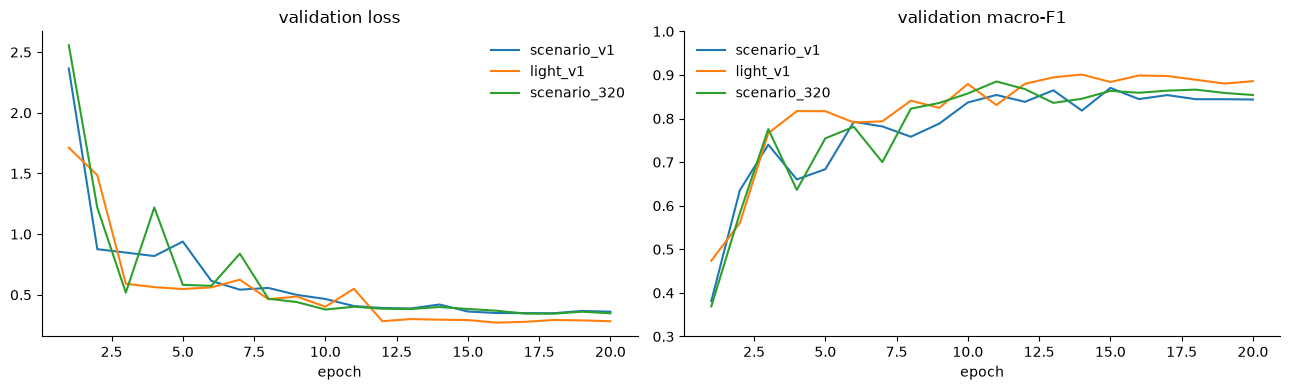

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for run in ALL_RUNS:
    h = pd.read_csv(RUNS / f"{run}.csv")
    axes[0].plot(h["epoch"], h["val_loss"], label=run)
    axes[1].plot(h["epoch"], h["val_macro_f1"], label=run)
axes[0].set_title("validation loss")
axes[1].set_title("validation macro-F1")
axes[1].set_ylim(0.3, 1)
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## Best checkpoint of each run on the validation set

In [4]:
results, cms = [], {}
for run in ALL_RUNS:
    model, ckpt = load_checkpoint(CHECKPOINTS / f"{run}_best.pt", device)
    cfg = ckpt["config"]
    dl = DataLoader(LeafDataset(SPLITS / "val.csv", mode="eval", size=cfg["size"]), batch_size=64, num_workers=4)
    logits, labels = predict(model, dl, device)
    preds = logits.argmax(1)
    recalls = recall_score(labels, preds, average=None, labels=range(len(CLASSES)))
    results.append({
        "run": run, "aug": cfg["aug"], "size": cfg["size"], "best epoch": ckpt["epoch"],
        "val acc": (preds == labels).float().mean().item(),
        "val macro-F1": f1_score(labels, preds, average="macro"),
        **{f"recall {c}": r for c, r in zip(CLASSES, recalls)},
    })
    cms[run] = confusion_matrix(labels, preds, labels=range(len(CLASSES)))

summary = pd.DataFrame(results).set_index("run")
summary.to_csv(RUNS / "summary_val.csv")
summary.round(3)

,aug,size,best epoch,val acc,val macro-F1,recall healthy,recall leaf_miner,recall rust,recall phoma,recall cercospora
run,,,,,,,,,,
scenario_v1,scenario,256,15,0.886,0.870,1.000,0.763,0.913,0.923,0.810
light_v1,light,256,14,0.915,0.901,1.000,0.895,0.928,0.923,0.810
scenario_320,scenario,320,11,0.905,0.885,0.952,0.947,0.928,0.904,0.714


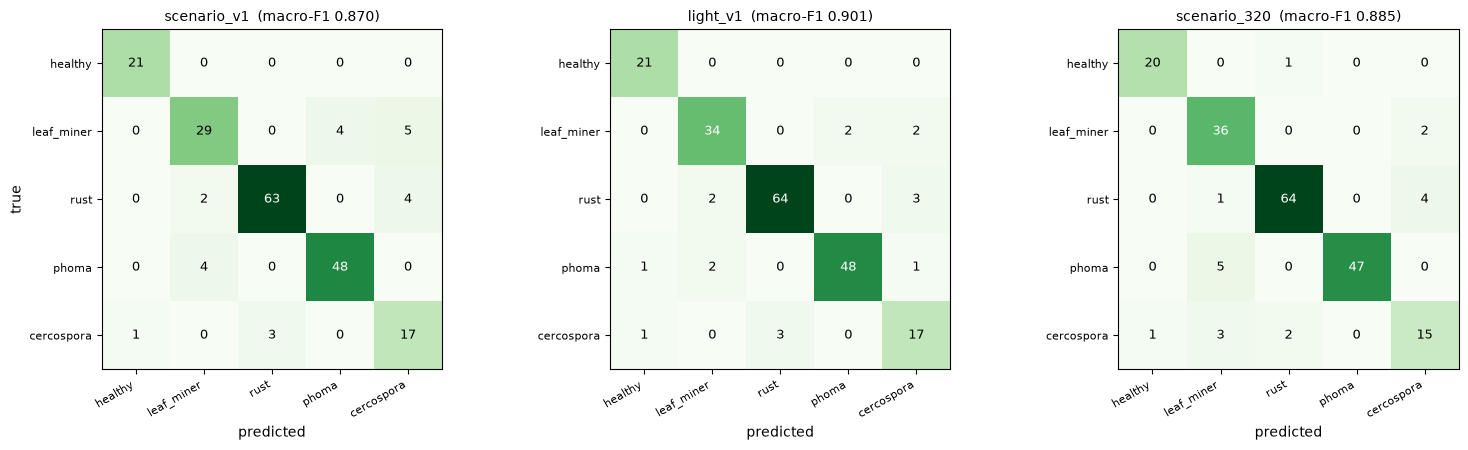

In [5]:
fig, axes = plt.subplots(1, len(cms), figsize=(5.2 * len(cms), 4.6))
for ax, (run, cm) in zip(axes, cms.items()):
    ax.imshow(cm, cmap="Greens")
    ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(CLASSES)), CLASSES, fontsize=8)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title(f"{run}  (macro-F1 {summary.loc[run, 'val macro-F1']:.3f})", fontsize=10)
    ax.set_xlabel("predicted")
axes[0].set_ylabel("true")
plt.tight_layout()